# Experiment on simulations n°2 - Optimal dimensionality reduction (see Section 5.1.3)

## Outline

[Content](#content)

[Prerequisite packages and settings](#prerequisite-packages-and-settings)

[Step 1: Traces generation and $\widehat{MI}$ computation](#step-1)

- [Step 1.1: Traces generation](#step-11)

- [Step 1.2: Computation of $\widehat{MI}$ for all traces sets](#step-12)

[Step 2: Instanciation of cVAE-OSM models and $\widehat{PI}$ computation](#step-2)

- [Step 2.1 Instanciation of cVAE-OSM models](#step-21)

- [Step 2.2: Training of cVAE-OSM models](#step-22)

- [Step 2.3: Computation of $\widehat{PI}$ for all traces sets](#step-23)

[Step 3: Visualization of $\widehat{MI}$ and $\widehat{PI}$](#step-3)

[References](#references)

## Content <a class='anchor' id='content'></a>

In this notebook, we propose to conduct the second experiment of our paper (see Section 5.1.3), in which we assess if cVAE-OSM performs an optimal dimensionality reduction.

To do so, we first generate traces, then compute the estimated mutual information $\widehat{MI}$ [BHM+19]. Then, we instanciate and train a cVAE-OSM model. Finally, according to parameters estimated by our model, we compute estimated perceived information $\widehat{PI}$ [BHM+19].

<u>CAUTION</u>: some of the cells in this notebook, especially in <a href="#step-22">Step 2.2</a> section,  may take a long time (several hours) to execute. 

## Prerequisite packages and settings <a class='anchor' id='prerequisite-packages-and-settings'></a>

Here are the Python packages and settings needed to run properly this notebook.

In [1]:
from cvae_osm_utils.generate_traces import *
from cvae_osm_utils.cVAE_OSM_model import *
from cvae_osm_utils.cVAE_OSM_tools import *
from cvae_osm_utils.experiments_tools import *
from matplotlib import pyplot as plt
import tensorflow as tf

# Enables Tensorflow program to run deterministically for reproducible results
tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

plt.rcParams['text.usetex'] = True

## Step 1: Traces generation and $\widehat{MI}$ computation <a class='anchor' id='step-1'></a>

### Step 1.1: Traces generation <a class='anchor' id='step-11'></a>

The generation of traces is done using a function called $\texttt{generate\_traces}$, available in $\texttt{generate\_traces.py}$ file. 

In the following example, we generate sets of $256,000$ traces of $D=150$ samples such that $10\%$ are PoIs. We consider the fourth scenario with a isotropic Gaussian noise of parameters $\mu=0$ and various $\sigma=\{0.1, 1, 25\}$.
The targeted byte is $0$ and the key is fixed. We set the seed to $42$ to have reproductible results. 

In [2]:
# Traces generation
targeted_byte = 0
sigma = [0.1, 1, 25]

traces_set = []
plaintexts_set = []
keys_set = []
targeted_variables_set = []
sigmas_set = []

for i in sigma:
    traces, plaintexts, keys, targeted_variables, sigmas = generate_traces(nb_traces=256000, nb_samples=150, nb_poi=15, mu=0, sigmas=np.array([i]), targeted_byte=targeted_byte, \
                            isotropic_noise=True, scenario='scenario_4', key_fixed=True, seed=42)

    traces_set.append(traces)
    plaintexts_set.append(plaintexts)
    keys_set.append(keys)
    targeted_variables_set.append(targeted_variables)
    sigmas_set.append(sigmas)
    
print("Traces generated \U00002705")

Traces generated ✅


Here is an example of generated traces.

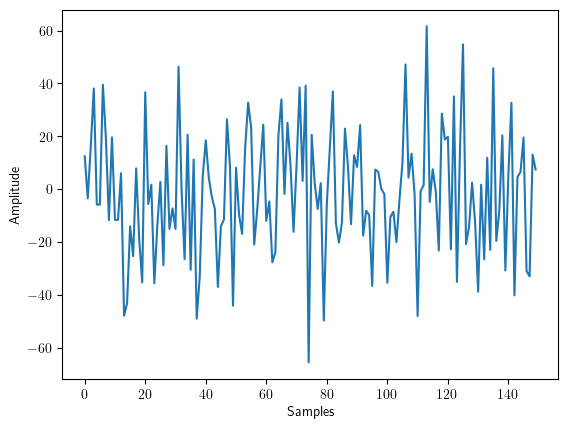

In [3]:
# Plot of a trace
plt.plot(traces_set[2][0,:])
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

### Step 1.2: Computation of $\widehat{MI}$ for all traces sets <a class='anchor' id='step-12'></a>

Then, for each set of generated traces, we compute $\widehat{MI}$ using $\texttt{mutual\_information}$ function (see $\texttt{experiments\_tools.py}$ file).

However, to do so, we first need to calculate the probability for each targeted variables value given the chosen leakage model. In our case, it corresponds to the multiple leakage model as we choose to generate traces following the fourth scenario. This probability can be computed using the function $\texttt{compute\_prob\_targeted\_variables}$, which is available in $\texttt{experiments\_tools.py}$ file.

We also need to compute the true mean of traces. To do so, we first retrieve exact coefficients of the leakage model when projecting into Guilley *et al.* orthonormal basis thanks to $\texttt{orthonormal\_basis\_computation\_true\_coeffs}$ function (see $\texttt{cVAE\_OSM\_tools.py}$ file). Then, using these coefficients, we retrieve the true mean of the traces by multiplying them by the projection into Guilley *et al.* orthonormal basis of the targeted variables values. This projection is done using $\texttt{orthonormal\_basis\_projection}$ function (see $\texttt{cVAE\_OSM\_tools.py}$ file).  

Finally, using true mean and probabilities previously computed, we can calculate $\widehat{MI}$.

In [4]:
MI = []
targeted_variables_possible_values = np.array([i for i in range(256)],  dtype='uint8')

# Computation of the probability of targeted values given a leakage model
prob_targeted_variables = compute_prob_targeted_variables(z=targeted_variables_possible_values, scenario="scenario_4")

# Projection of possible values of targeted variables onto Guilley etal. orthonormal basis
# We consider the full basis (len_basis=256) i.e. all the monomials len_basis=256
# One can also consider other configurations
# For example, when considering only the monomials individually i.e. without interactions between them, len_basis=9
projection_targeted_variables_possible_values = orthonormal_basis_projection(targeted_variables_possible_values, max_nb_monomials_interactions=8, len_basis=256)

# Computation of MI for all traces
for i in range(len(sigma)):

    # 1. Computation of the true mean
    
    # 1.1 Computation of exact values of true leakage model coefficients 
    exact_coeffs = orthonormal_basis_computation_true_coeffs(traces_set[i], targeted_variables_set[i][:, targeted_byte], max_nb_monomials_interactions=8)
    
    # 1.2 Computation of true mean of traces
    true_mean = projection_targeted_variables_possible_values @ exact_coeffs.T

    # 2. Computation of Mutual Information (MI)
    mi = mutual_information(traces_set[i], true_mean, sigma[i]**2, prob_targeted_variables)
    MI.append(mi)

print("MIs computation done \U00002705")

MIs computation done ✅


## Step 2: Instanciation of cVAE-OSM models and $\widehat{PI}$ computation <a class='anchor' id='step-2'></a>

### Step 2.1 Instanciation of cVAE-OSM models <a class='anchor' id='step-21'></a>

After generating traces and computing $\widehat{MI}$, we instanciate cVAE-OSM models for each set of traces by calling $\texttt{cVAE}$ class (see $\texttt{cVAE\_OSM\_model.py}$ file) . 
As for traces generation, to enable reproductible results, we set the seed to a fixed value. In this case, we choose $\texttt{seed}=42$.

Before models instanciations, we first need to compute the projection of targeted variables onto Guilley *et al.* basis, considering all bits interactions, thus $\texttt{len\_basis}=256$.

Then considering various learning rates, we create several cVAE-OSM (one for each set of traces) and compile models.

In [5]:
cVAE_models = []

nb_samples = traces_set[0].shape[1]
learning_rate = [0.001, 0.001, 1.5e-4]
max_nb_monomials_interactions, len_basis = 8, 256

for i in range(len(sigma)):

    # Instanciation of encoder and decoder
    encoder = define_encoder(input_size=nb_samples, len_basis=len_basis, is_deterministic=True, seed=42)
    decoder = define_decoder(input_size=nb_samples, len_basis=len_basis, is_deterministic=True, seed=42)

    # Instanciation of cVAE-OSM model
    cVAE_OSM = cVAE(encoder, decoder)

    # Compilation of cVAE-OSM model
    cVAE_OSM.compile(optimizer=keras.optimizers.Adam(learning_rate[i]))

    cVAE_models.append(cVAE_OSM)

print("Models created \U00002705")


Models created ✅


### Step 2.2: Training of cVAE-OSM models <a class='anchor' id='step-22'></a>

Once models are created, we train models using their respective simulated traces and projection of targeted variables into the orthonormal basis.

This projection onto Guilley *et al.* basis is computed using $\texttt{orthonormal\_basis\_projection}$ function, which is available in $\texttt{cVAE\_OSM\_tools.py}$ file. We consider all bits interactions, thus $\texttt{len\_basis}=256$.

For all models, training is done for $200$ epochs using a batch size set to $8$.

<u>CAUTION</u>: the following cell may take a long time (several hours) to execute. 

By way of comparison, this cell takes about $9$ hours to run on a laptop equipped with $8$ GB RAM and a $2.6$ GHz Intel Core i7-9750H processor.

In [6]:
# CAUTION: this cell may take a long time (several hours) to execute. 

# cVAE-OSM training
batch_size = 8
epochs = 200
for i in range(len(sigma)):

    # Projection of targeted variables onto Guilley etal. orthonormal basis considering all monomials interactions
    projection_targeted_variables = orthonormal_basis_projection(targeted_variables_set[i][:, targeted_byte], max_nb_monomials_interactions, len_basis)

    # Training of cVAE-OSM models
    cVAE_models[i].fit([traces_set[i], projection_targeted_variables], epochs=epochs, batch_size=batch_size)

    tf.keras.backend.clear_session()

print("Training done \U00002705")

Epoch 1/200
32000/32000 [==============================] - 80s 2ms/step - ELBO loss: 71.3216 - reconstruction_loss: 9.4820 - kl_loss: 1.3246
Epoch 2/200
32000/32000 [==============================] - 74s 2ms/step - ELBO loss: -65.6116 - reconstruction_loss: -77.5854 - kl_loss: 0.3566
Epoch 3/200
32000/32000 [==============================] - 66s 2ms/step - ELBO loss: -104.1919 - reconstruction_loss: -111.2257 - kl_loss: 0.6394
Epoch 4/200
32000/32000 [==============================] - 66s 2ms/step - ELBO loss: -123.4657 - reconstruction_loss: -125.6367 - kl_loss: 0.4376
Epoch 5/200
32000/32000 [==============================] - 66s 2ms/step - ELBO loss: -128.2821 - reconstruction_loss: -129.2229 - kl_loss: 0.5193
Epoch 6/200
32000/32000 [==============================] - 61s 2ms/step - ELBO loss: -129.4629 - reconstruction_loss: -130.0844 - kl_loss: 0.5327
Epoch 7/200
32000/32000 [==============================] - 54s 2ms/step - ELBO loss: -129.7430 - reconstruction_loss: -130.2813 - k

### Step 2.3: Computation of $\widehat{PI}$ for all traces sets <a class='anchor' id='step-23'></a>

Now that models are trained, we can computed $\widehat{PI}$ using deterministic part coefficients and variance estimated by cVAE-OSM models. 



In [7]:
PI = []

# Computation of PI for all traces
for i in range(len(sigma)):

    # 1. Computation of the mean estimated by cVAE-OSM models 

    # 1.1 Getting back leakage model coefficients estimated
    estimated_coeffs = cVAE_models[i].decoder.get_layer('psi_layer_decoder').weights[0].numpy()
    
    # 1.2 Computation of estimated mean of traces
    estimated_mean = projection_targeted_variables_possible_values @ estimated_coeffs

    # 1.3 Getting back variance estimated
    inv_estimated_variance = cVAE_models[i].encoder.get_layer('z_mean').weights[0].numpy()
    estimated_variance = 1/inv_estimated_variance

    # 2. Computation of Perceived Information (PI)
    pi = mutual_information(traces_set[i], estimated_mean, estimated_variance, prob_targeted_variables)
    PI.append(pi)

print("PIs computation done \U00002705")

PIs computation done ✅


## Step 3: Visualization of $\widehat{MI}$ and $\widehat{PI}$ <a class='anchor' id='step-3'></a>

Finally, we can visualize $\widehat{MI}$ and $\widehat{PI}$ previously computed.

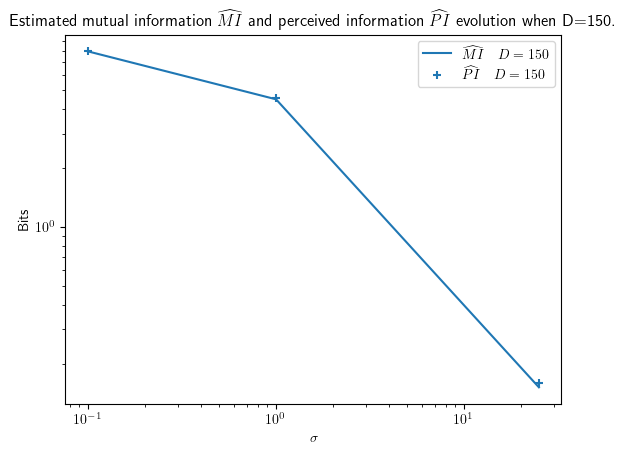

In [8]:
# Plot of MI and PI using a logarithmic scale

plt.plot(sigma, MI, label=r'$\widehat{MI} \quad D=150$')
plt.scatter(sigma, PI, label=r'$\widehat{PI} \quad D=150$', marker='+')

plt.xlabel(r'$\sigma$')
plt.ylabel(r'Bits')
plt.title(r'Estimated mutual information $\widehat{MI}$ and perceived information $\widehat{PI}$ evolution when D=150.')
plt.legend()

plt.xscale('log')
plt.yscale('log')
plt.show() 

All the results obtained through this notebook are in line with those reported in Section 5.1.3.

Indeed, $\widehat{MI}$ and $\widehat{PI}$ scores obtained are similar. This consequently means that parameters estimated by cVAE-OSM, namely leakage model and variance, are sufficient to accurately describe traces. 

Hence, the dimensionality reduction performed within cVAE-OSM is done without any loss of information.

## References <a class='anchor' id='references'></a>

[BHM+19] Olivier Bronchain, Julien M. Hendrickx, Clément Massart, Alex Olshevsky, and François-Xavier Standaert. 
         Leakage certification revisited: Bounding model errors in side-channel security evaluations. 
         In Advances in Cryptology – CRYPTO 2019: 39th Annual International Cryptology Conference, Santa Barbara, 
         CA, USA, August 18–22, 2019, Proceedings, Part I, page 713–737, Berlin, Heidelberg, 2019. Springer-Verlag.